# 03 — What is a Basis?

**The question:** what is an orthonormal basis of a function space, and why do the eigenfunctions of the Laplace-Beltrami operator give us the *right* one for shapes?

## Intuition

In 1D, the Fourier basis tells us that *any* periodic signal can be written as a sum of sines and cosines. The key properties are:

1. **Completeness** — you can represent anything with enough terms.
2. **Orthogonality** — basis functions do not "overlap": $\langle \phi_i, \phi_j \rangle = 0$ for $i \neq j$.
3. **Ordering** — low-index functions are smooth; high-index ones are oscillatory.

On a surface we use the **eigenfunctions of the Laplace-Beltrami operator** (introduced in notebook 02) as the analogous basis. Because the LBO is self-adjoint and positive semi-definite on $L^2(M)$, its eigenfunctions inherit all three properties and are *intrinsic* to the geometry — they do not depend on how the shape is embedded in 3D space.

The eigenvalues $\lambda_k$ play the role of **squared frequencies**: small $\lambda_k$ means the eigenfunction varies slowly; large $\lambda_k$ means it oscillates rapidly.

## Minimal math

An **orthonormal basis** $\{\phi_k\}_{k=0}^{\infty}$ of $L^2(M)$ satisfies:

$$\langle \phi_i, \phi_j \rangle_M = \phi_i^\top M\, \phi_j = \delta_{ij}$$

Any function $f \in L^2(M)$ decomposes as:

$$f = \sum_{k=0}^{\infty} a_k \, \phi_k, \qquad a_k = \langle f, \phi_k \rangle_M = \phi_k^\top M\, \mathbf{f}$$

The vector $\mathbf{a} = (a_0, a_1, \ldots)$ holds the **spectral coefficients** of $f$. In practice we truncate at $K$ basis functions:

$$f \approx \hat{f}_K = \Phi_K\, \mathbf{a}_K, \qquad \Phi_K \in \mathbb{R}^{n \times K}$$

**Parseval's identity** ties the $L^2(M)$ norm to the coefficient vector:

$$\|f\|_M^2 = \sum_{k=0}^{\infty} a_k^2$$

The approximation error is:

$$\|f - \hat{f}_K\|_M^2 = \sum_{k \geq K} a_k^2$$

Smooth functions decay fast — a few coefficients capture most of the energy. Rough functions need many.

In [1]:
import gsops.backend as gs
import matplotlib.pyplot as plt
import numpy as np
import polyscope as ps

from geomfum.dataset import NotebooksDataset
from geomfum.shape import TriangleMesh

ps.init()

## Toy example: 1D Fourier basis

Before going to shapes, let us look at the Fourier basis on $[0, 2\pi]$.

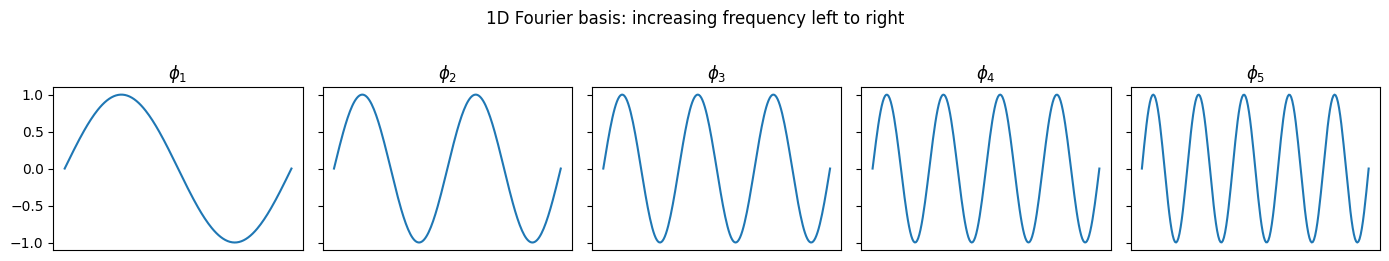

In [2]:
x = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 5, figsize=(14, 2.5), sharey=True)
for k, ax in enumerate(axes):
    phi = np.sin((k + 1) * x)
    ax.plot(x, phi)
    ax.set_title(f"$\\phi_{k + 1}$")
    ax.set_xticks([])
plt.suptitle("1D Fourier basis: increasing frequency left to right", y=1.02)
plt.tight_layout()
plt.show()

C:\Users\giuli\AppData\Local\Temp\ipykernel_18340\1141766298.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  a_k = np.trapz(step * phi, x) / np.pi


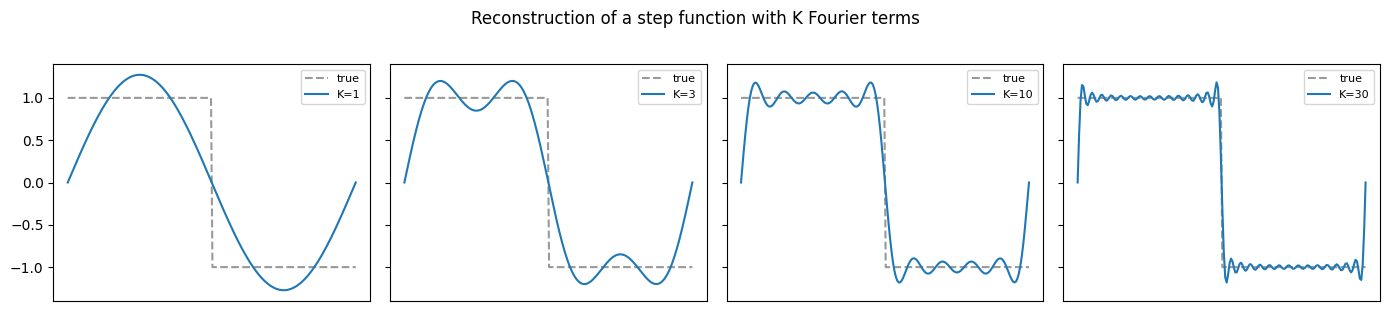

In [3]:
# Approximate a step function with a truncated Fourier series
step = (x < np.pi).astype(float) * 2 - 1  # +1 on [0,pi), -1 on [pi,2pi)

fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
for K_toy, ax in zip([1, 3, 10, 30], axes):
    approx = np.zeros_like(x)
    for k in range(1, K_toy + 1):
        phi = np.sin(k * x)
        a_k = np.trapz(step * phi, x) / np.pi
        approx += a_k * phi
    ax.plot(x, step, "k--", alpha=0.4, label="true")
    ax.plot(x, approx, label=f"K={K_toy}")
    ax.legend(fontsize=8)
    ax.set_xticks([])
plt.suptitle("Reconstruction of a step function with K Fourier terms", y=1.02)
plt.tight_layout()
plt.show()

## Shape basis: LBO eigenfunctions

On a 3D mesh the role of Fourier modes is played by the **eigenfunctions of the Laplace-Beltrami operator**. These are the solutions to $S\phi_k = \lambda_k M\phi_k$ (notebook 02). We compute the first $K$ of them with `find_spectrum`.

In [4]:
dataset = NotebooksDataset()
mesh = TriangleMesh.from_file(dataset.get_filename("cat-00"))

K = 50
mesh.laplacian.find_spectrum(spectrum_size=K, set_as_basis=True)

lam = mesh.basis.vals  # (K,) eigenvalues
Phi = mesh.basis.vecs  # (n, K) eigenvectors (M-orthonormal)

print(f"Basis vectors shape: {Phi.shape}   (n_vertices × K)")
print(f"Eigenvalues shape:   {lam.shape}")

Basis vectors shape: (7207, 50)   (n_vertices × K)
Eigenvalues shape:   (50,)


## The eigenvalue spectrum

The eigenvalues $\lambda_k$ encode the **intrinsic frequency** of each basis function:
- $\lambda_0 = 0$: the constant function (zero gradient everywhere)
- $\lambda_k$ grows monotonically — higher index means higher frequency

The growth rate of $\lambda_k$ depends on the shape's geometry — it is an intrinsic fingerprint of the surface.

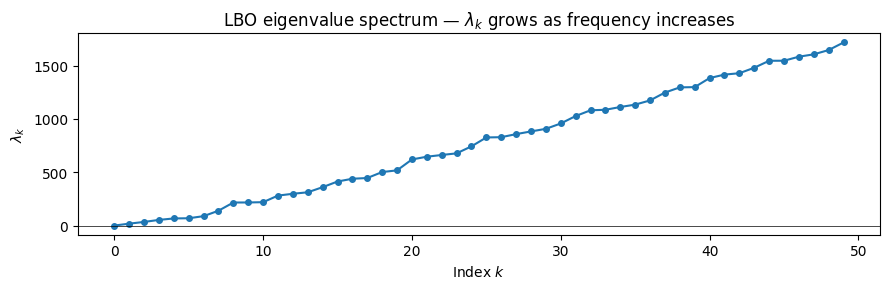

λ_0 = 0.000000  (constant function — kernel of Δ)
λ_1 = 17.9035,  λ_10 = 219.1368,  λ_49 = 1715.7202


In [5]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(np.arange(K), lam, "o-", markersize=4)
ax.set_xlabel("Index $k$")
ax.set_ylabel("$\\lambda_k$")
ax.set_title("LBO eigenvalue spectrum — $\\lambda_k$ grows as frequency increases")
ax.axhline(0, color="k", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"λ_0 = {lam[0]:.6f}  (constant function — kernel of Δ)")
print(f"λ_1 = {lam[1]:.4f},  λ_10 = {lam[10]:.4f},  λ_49 = {lam[49]:.4f}")

## Visualise the eigenfunctions

We add several eigenfunctions to polyscope as toggleable scalar quantities. Low-index eigenfunctions are globally smooth; high-index ones oscillate rapidly — exactly like Fourier modes on an interval.

In [6]:
V = mesh.vertices
F = mesh.faces

ps.remove_all_structures()
ps_cat = ps.register_surface_mesh("cat", V, F, smooth_shade=True)

for k in [1, 5, 10, 20, 49]:
    ps_cat.add_scalar_quantity(
        f"phi_{k:02d}  (λ={lam[k]:.2f})",
        Phi[:, k],
        enabled=(k == 1),
        cmap="coolwarm",
    )

print("Toggle eigenfunctions in the polyscope GUI.")
print("Low k → globally smooth.   High k → rapidly oscillating.")
ps.show()

Toggle eigenfunctions in the polyscope GUI.
Low k → globally smooth.   High k → rapidly oscillating.


## Project a function and reconstruct it

We project the height function $f_z$ onto the eigenbasis using `mesh.basis.project`, which computes $a_k = \phi_k^\top M\, \mathbf{f}$ for all $k$ at once. Then we reconstruct with an increasing number of modes.

In [7]:
f_z = mesh.vertices[:, 2] ** 4

# Spectral coefficients: a = Φ^T M f  (geomfum native, uses mass matrix internally)
a = mesh.basis.project(f_z)  # shape (K,)

print(f"Largest 5 coefficients (by |a_k|): indices {np.abs(a).argsort()[::-1][:5]}")
print(
    f"Energy captured by first 5 modes:  {(a[:5] ** 2).sum() / (a**2).sum() * 100:.1f}%"
)
print(
    f"Energy captured by first 20 modes: {(a[:20] ** 2).sum() / (a**2).sum() * 100:.1f}%"
)

Largest 5 coefficients (by |a_k|): indices [2 0 8 1 3]
Energy captured by first 5 modes:  79.7%
Energy captured by first 20 modes: 98.3%


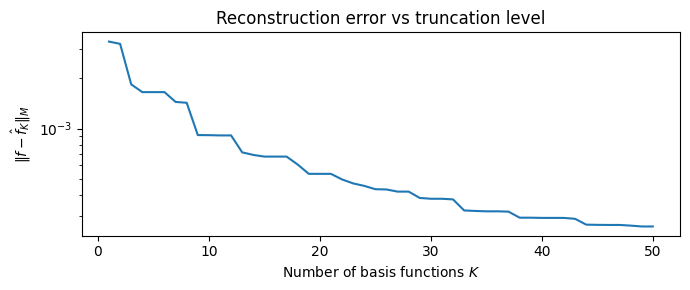

In [8]:
# Reconstruction error vs number of modes
a_vec = mesh.vertex_areas  # diagonal of M, shape (n,)

ks = list(range(1, K + 1))
errors = []
for k in ks:
    f_hat = Phi[:, :k] @ a[:k]
    diff = f_z - f_hat
    errors.append(np.sqrt(np.sum(diff**2 * a_vec)))  # ||f - f_hat||_M

plt.figure(figsize=(7, 3))
plt.semilogy(ks, errors)
plt.xlabel("Number of basis functions $K$")
plt.ylabel("$\\|f - \\hat{f}_K\\|_M$")
plt.title("Reconstruction error vs truncation level")
plt.tight_layout()
plt.show()

In [9]:
# Visualise the reconstruction quality at K = 5 and K = 20
f_hat_5 = Phi[:, :5] @ a[:5]
f_hat_20 = Phi[:, :20] @ a[:20]

ps.remove_all_structures()
ps_cat = ps.register_surface_mesh("cat", V, F, smooth_shade=True)
ps_cat.add_scalar_quantity("f_z (original)", f_z, enabled=True, cmap="viridis")
ps_cat.add_scalar_quantity("f_hat  K=5", f_hat_5, enabled=False, cmap="viridis")
ps_cat.add_scalar_quantity("f_hat  K=20", f_hat_20, enabled=False, cmap="viridis")

print("Toggle between 'f_z (original)', 'f_hat K=5', and 'f_hat K=20' in polyscope.")
ps.show()

Toggle between 'f_z (original)', 'f_hat K=5', and 'f_hat K=20' in polyscope.


## Where to go next

- [04 — Tangent Vectors and Vector Fields](./04_tangent_vectors_and_operators.ipynb): vector fields and gradients on surfaces
- [05 — Spectral Filtering](./05_spectral_filtering.ipynb): use the basis to design filters and descriptors